# Simulation of a silicon solar cell

The following code loads the needed modules.

In [1]:
import numpy as np

import matplotlib.pyplot as plt

from synumses.one_dimension.scharfetter_gummel_bernoulli import bernoulli, jacobian, update_b, first_jacobian, first_update_b, hole_current_density, electron_current_density

import synumses.one_dimension.parameters as parameters

from synumses.one_dimension.functions import calc_p_density, calc_n_density, calc_recombination

import synumses.one_dimension.solver as solver

## Definition of the solar cell
The silicon has a thickness of $l_\mathrm{x}=1\,\mathrm{\mu m}$ and the pn junction is at $x=40\,\mathrm{nm}$.<br>
The p-doping is much higer compared to th n-doping.<br>
There is no recombination.

In [2]:
parameters.n = 500 #1000
parameters.lx = 1000E-9

parameters.init_geometry()

parameters.init_parameters()

#parameters.Cau = 0*1E-24

Na = 1.0E24
Nd = 4.0E22

Chi = 4.05
Eg  = 1.12

# pn transistion at x1
x1 = 40E-9

for i in range(0, parameters.n):
    
    parameters.Chi[i] = Chi
    parameters.Eg[i]  = Eg
    
    if parameters.pos_x[i] < x1:
        
        parameters.C[i]  = -Na
    else:       
        parameters.C[i]  = Nd

## Plot band diagram and the doping levels

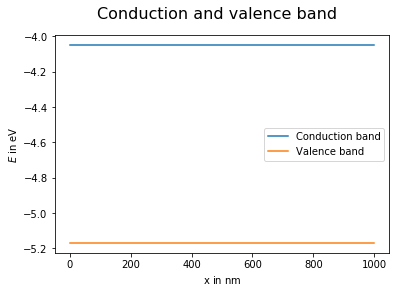

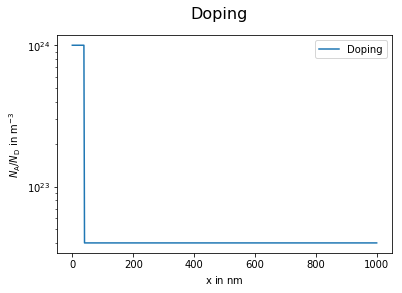

In [3]:
#
# Band diagram
#
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Conduction and valence band", fontsize=16)

axis.plot(parameters.pos_x * 1E9, -parameters.Chi, label='Conduction band')
axis.plot(parameters.pos_x * 1E9, -parameters.Chi-parameters.Eg, label='Valence band')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$E$ in $\mathrm{eV}$")

axis.legend()
plt.show()

#
# Doping level
#
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Doping", fontsize=16)

axis.semilogy(parameters.pos_x * 1E9, np.abs(parameters.C), label='Doping')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$N_\mathrm{A} / N_\mathrm{D}$ in $\mathrm{m^{-3}}$")

axis.legend()
plt.show()


## Solving without biasing
Now, let's apply a voltage of $0\,\mathrm{mV}$!.

In [4]:
solver.solve_from_doping()

solver.solve_no_bias()
bias_point = 0.0

solver.solve_bias(bias_point,0)

/home/pabele/anaconda3/lib/python3.7/site-packages/scipy/sparse/linalg/dsolve/linsolve.py:133: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  SparseEfficiencyWarning)


Norm of b:  346259767.8720046
Norm of x: 0.22037631941412128
Norm of b:  14247030.677492416
Norm of x: 0.07057158707315761
Norm of b:  38574.200980582646
Norm of x: 0.00789003556951574
Norm of b:  5.136460166504469
Norm of x: 0.00010948616644300616
Norm of b:  0.0004942073184570563
Norm of x: 2.5316820443179268e-08


True

## Plot the potential

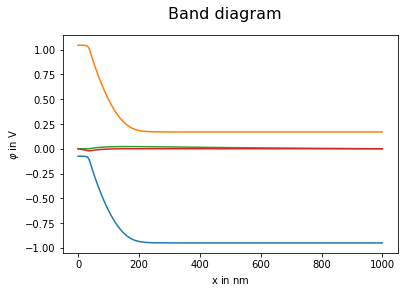

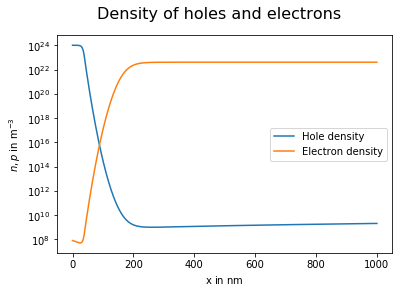

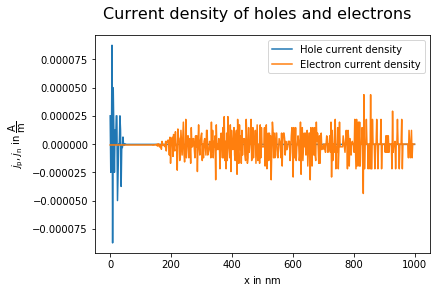

In [5]:
#
# Plot band diagram
#
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Band diagram", fontsize=16)

axis.plot(parameters.pos_x * 1E9, -parameters.u[0::3] - parameters.Chi -  parameters.Eg, label='Valence band')
axis.plot(parameters.pos_x * 1E9, -parameters.u[0::3] - parameters.Chi                 , label='Conduction band')
axis.plot(parameters.pos_x * 1E9, -parameters.u[1::3]                                  , label='Quasi-Fermi-level of holes')
axis.plot(parameters.pos_x * 1E9, -parameters.u[2::3]                                  , label='Quasi-Fermi-level of electrons')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$\varphi$ in $\mathrm{V}$")

plt.show()

#
# Electron and hole density
#
calc_p_density()
calc_n_density()
p = calc_p_density()
n = calc_n_density()

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Density of holes and electrons", fontsize=16)

axis.semilogy(parameters.pos_x * 1E9, p, label='Hole density')
axis.semilogy(parameters.pos_x * 1E9, n, label='Electron density')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$n,p$ in $\mathrm{m^{-3}}$")

axis.legend()
plt.show()


# Electron and hole current density 
j_p =     hole_current_density()
j_n = electron_current_density()

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Current density of holes and electrons", fontsize=16)

axis.plot(parameters.pos_x * 1E9, j_p, label='Hole current density')
axis.plot(parameters.pos_x * 1E9, j_n, label='Electron current density')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$j_\mathrm{p}, j_\mathrm{n}$ in $\mathrm{\dfrac{A}{m}}$")

axis.legend()
plt.show()

## Simulation with illumination
Now we illuminate the solar cell and simulate the short circuit current density.<br>
We assume a powerdensity of $1\,\mathrm{\dfrac{kW}{m^3}}$,
an absorption coefficient for silicon of $\alpha_\mathrm{Si} = 2.0\cdot 10^{6}\,\mathrm{m^{-1}}$, and
a light efficiency of $\eta = 0.6$. <br>
For the simulation to converge, the illumination must be ramped up, this takes some time.<br>


In [6]:
# For the simulatoin the illumination starts
# 10nm after and stops 10nm before the contacts.
x1 = 10E-9
x2 = 990E-9


bias_point = 0.0

eta = 0.6

I0 = 1E3

alpha = 2E6

dI0 = alpha*I0*eta

steps = 23

for i in range(steps):

    print("Step:", i,
          "Generation rate at the surface",
          dI0/(2**steps) * 2**(i+1) /(parameters.q * Eg))

    parameters.generation = np.where((parameters.pos_x  > x1) & (parameters.pos_x < x2),
                                     dI0/(2**steps) * 2**(i+1) * np.exp(-parameters.pos_x*alpha) /(parameters.q * Eg),
                                     0)

    solver.solve_bias(-bias_point,0)
    
    j = np.mean(hole_current_density() + electron_current_density())
    
    print("\t Current density:", j)
    

Step: 0 Generation rate at the surface 1.596552985055106e+21
Norm of b:  0.0005086919767795162
Norm of x: 9.948791173939869
Norm of b:  726930.3962159514
Norm of x: 0.5062944869700047
Norm of b:  267422.7479304522
Norm of x: 0.49740797740199777
Norm of b:  98379.3310651919
Norm of x: 0.4889535221243541
Norm of b:  36191.73333508764
Norm of x: 0.48057664148323676
Norm of b:  13314.194634343303
Norm of x: 0.47225289665567893
Norm of b:  4898.01848173537
Norm of x: 0.46390583823999537
Norm of b:  1801.8803019136296
Norm of x: 0.45547235752343035
Norm of b:  662.8747185313528
Norm of x: 0.4468894984680026
Norm of b:  243.857981026063
Norm of x: 0.43809673182541387
Norm of b:  89.71033779246031
Norm of x: 0.42903330513247095
Norm of b:  33.002588944037285
Norm of x: 0.41963427250871854
Norm of b:  12.140973997447555
Norm of x: 0.4098262584028776
Norm of b:  4.466414764102358
Norm of x: 0.39952226342527025
Norm of b:  1.6431022616803572
Norm of x: 0.38861458654974423
Norm of b:  0.6044637585

## Plot the parameters with illumination
* generation rate,
* hole and electron density, and
* hole and electron current density.

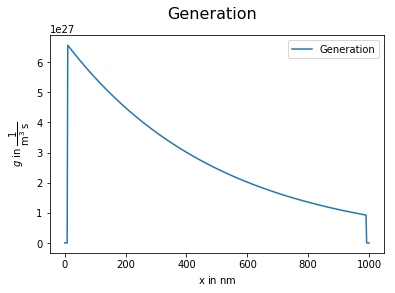

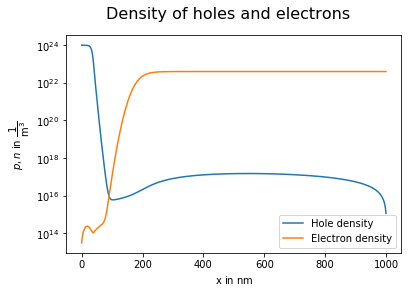

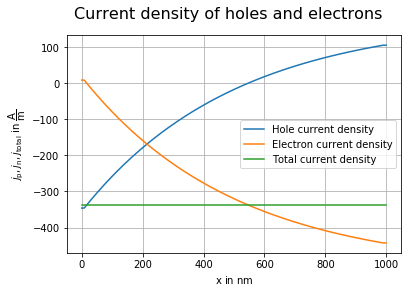

In [7]:
#
# Plot generation rate
#
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Generation", fontsize=16)

axis.plot(parameters.pos_x * 1E9, parameters.generation, label='Generation')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$g$ in $\mathrm{\dfrac{1}{m^3\, s}}$")

axis.legend()
plt.show()

#
# PLot hole and electron density
#
calc_p_density()
calc_n_density()

p = calc_p_density()
n = calc_n_density()

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Density of holes and electrons", fontsize=16)

axis.semilogy(parameters.pos_x * 1E9, p, label='Hole density')
axis.semilogy(parameters.pos_x * 1E9, n, label='Electron density')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$p, n$ in $\mathrm{\dfrac{1}{m^3}}$")

axis.legend()
plt.show()

#
# Plot hole and electron current density 
#
j_p =     hole_current_density()
j_n =     electron_current_density()

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Current density of holes and electrons", fontsize=16)

axis.plot(parameters.pos_x * 1E9, j_p, label='Hole current density')
axis.plot(parameters.pos_x * 1E9, j_n, label='Electron current density')
axis.plot(parameters.pos_x * 1E9, j_n+j_p, label='Total current density')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$j_\mathrm{p}, j_\mathrm{n}, j_\mathrm{total}$ in $\mathrm{\dfrac{A}{m}}$")

axis.legend()
axis.grid()
plt.show()

## Voltage sweep
Now, the voltage is swept to get the characteristics of the solar cell for illumination

In [8]:
u_start = 0.0
u_stop  = 0.50
u_step  = 0.025

voltage = []
current_density = []

bias_points = np.linspace(u_start, u_stop, int((u_stop-u_start)/u_step) + 2)
for bias_point in bias_points:

    solver.solve_bias(bias_point,0)   
    
    j = np.mean(hole_current_density() + electron_current_density())
    voltage.append(bias_point)
    current_density.append(j)
    print(bias_point, ",", j)
  

Norm of b:  0.00048608163694141034
Norm of x: 4.5310753955701385e-14
0.0 , -337.05825128405706
Norm of b:  85707983456.52519
Norm of x: 0.27379454061141484
Norm of b:  264352.1993833619
Norm of x: 0.0035117941120713114
Norm of b:  12.810073425817139
Norm of x: 7.173615383382455e-05
Norm of b:  0.0005856610067117566
Norm of x: 4.5640549955192884e-08
0.023809523809523808 , -336.4891466252508
Norm of b:  85708118500.59506
Norm of x: 0.27277799249018575
Norm of b:  266096.518452679
Norm of x: 0.0036307535312836573
Norm of b:  13.403225454672187
Norm of x: 7.681418320412117e-05
Norm of b:  0.0006363578341525474
Norm of x: 5.2238982005684196e-08
0.047619047619047616 , -335.9093130971637
Norm of b:  85708252249.62376
Norm of x: 0.27175609044685195
Norm of b:  268017.3556379967
Norm of x: 0.003759246792777023
Norm of b:  14.047286494557264
Norm of x: 8.245945653508562e-05
Norm of b:  0.0006701230018007947
Norm of x: 6.007717778016334e-08
0.07142857142857142 , -335.3182156489312
Norm of b:  857

## Plot solar cell characteristics
* the current density and 
* the power density.

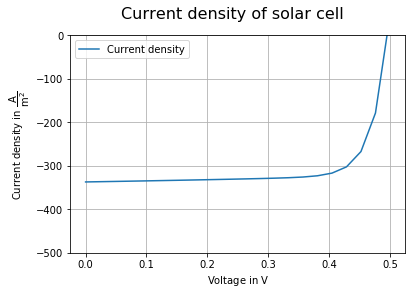

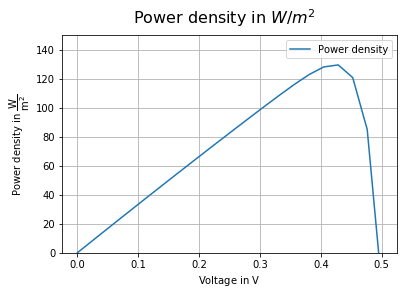

In [9]:
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Current density of solar cell", fontsize=16)

axis.plot(voltage, current_density, label='Current density')

axis.set_xlabel(r"Voltage in $\mathrm{V}$")
axis.set_ylabel(r"Current density in $\mathrm{\dfrac{A}{m^2}}$")

axis.legend()
axis.grid()
plt.ylim(-500,0)
plt.show()


# Power density
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Power density in $W/m^2$", fontsize=16)

axis.plot(voltage, -np.array(current_density)*np.array(voltage), label='Power density')

axis.set_xlabel(r"Voltage in $\mathrm{V}$")
axis.set_ylabel(r"Power density in $\mathrm{\dfrac{W}{m^2}}$")

axis.legend()
axis.grid()
plt.ylim(0,150)
plt.show()